In [35]:
import darts
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm

In [12]:
import polars as pl

# 1. Scan
lf = pl.scan_csv("data.csv")

# 2. Transformation
processed_lf = (
    lf.with_columns([
        # Use str.slice to handle the " UTC" suffix efficiently
        pl.col("timedate")
          .str.slice(0, 19) 
          .str.to_datetime("%Y-%m-%d %H:%M:%S")
          .dt.truncate("1h")
          .alias("hour")
    ])
    .group_by(["deviceId", "period", "hour"])
    .agg([
        # Calculate mean for temperature columns t1 through t13
        # This regex ensures we only pick columns that are 't' followed by digits
        pl.col("^t\d+$").mean(), 
        
        # Other metrics
        pl.col("x1").mean(),
        pl.col("x2").mean(),
        pl.col("t1").min().alias("t1_min"),
        pl.col("t1").max().alias("t1_max"),
        pl.col("x3").first(),
        pl.col("deviceType").first()
    ])
    .sort(["deviceId", "hour"])
)

# 3. Single-pass execution
print("Starting aggregation (streaming 10GB)...")
final_df = processed_lf.collect(streaming=True)

print("Splitting and saving files...")
for p in ["train", "test", "valid"]:
    subset = final_df.filter(pl.col("period") == p)
    if not subset.is_empty():
        subset.write_csv(f"{p}_hourly.csv")
        print(f"✅ Saved {p}_hourly.csv ({len(subset)} rows)")

<>:20: SyntaxWarning: invalid escape sequence '\d'
<>:20: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_23663/2720612027.py:20: SyntaxWarning: invalid escape sequence '\d'
  pl.col("^t\d+$").mean(),
/tmp/ipykernel_23663/2720612027.py:35: DeprecationWarning: the `streaming` parameter was deprecated in 1.25.0; use `engine` instead.
  final_df = processed_lf.collect(streaming=True)


Starting aggregation (streaming 10GB)...
Splitting and saving files...
✅ Saved train_hourly.csv (2905879 rows)
✅ Saved test_hourly.csv (1660460 rows)
✅ Saved valid_hourly.csv (841834 rows)


In [36]:
devices = pd.read_csv('devices.csv')
devices

,latitude,longitude,deviceId
0,50.0,18.3,000cc3cb7f030c3d0c481bd0e7cf42ee283012c3cb5bfc...
1,53.5,21.1,005767201ec5d7c3336b3b4d1ffa8a72e7ca1ecdaac30f...
2,52.9,18.1,01668c64ccc16c506a7c1a5c032e2eb5e2de48ecb284f2...
3,52.5,17.7,01bf745bf2df0312bd5ff2234c0e9dedc39ad0bac9bcfc...
4,50.7,16.7,02e4ad5d8d0016d35a003ea6df7e10fe27093aba81c64a...
...,...,...,...
595,52.4,14.6,fbdf266dd372334fcd865972f980574608f7fc122ecf6c...
596,54.6,18.1,fc376d9b600a622120a38da673f71d121b850055851e26...
597,51.9,19.6,fd2d77f969dd205ffe471e2349d3d2f54dc6e30a7d2ccd...
598,51.5,21.5,fdd1157e24eae9617881107d653c75ee16234d3bb7d84f...


In [4]:
df = pd.read_csv('train_hourly.csv')
df["timedate"] = pd.to_datetime(df["hour"], utc=True)

df["year"] = df["timedate"].dt.year
df["month"] = df["timedate"].dt.month
df["hour"] = df["timedate"].dt.hour


<Axes: xlabel='hour'>

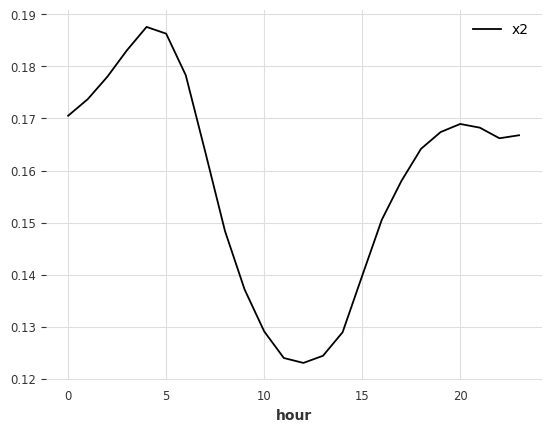

In [85]:
df.groupby('hour')['x2'].mean().reset_index().plot(x='hour', y='x2')

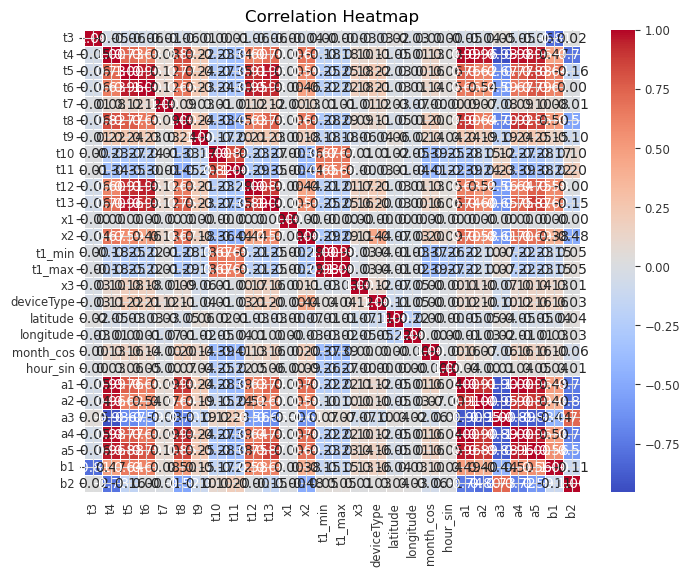

In [29]:
import seaborn as sns

df = pd.read_csv('train_hourly.csv')
df = augment_df(df)

#df_squared = df.copy()
#df_squared.loc[:, df_squared.columns != 'x2'] = np.log(df_squared.loc[:, df_squared.columns != 'x2'])

#df = df_squared

df['a1'] = df['t4'] * df['t8']
df['a2'] = df['t4'] / df['t8']
df['a3'] = df['t8'] / df['t4']
df['a4'] = df['t4'] + df['t8']
df['a5'] = df['t4'] * df['t13']

df['b1'] = df['t5'] - df['t3']
df['b2'] = df['t6'] - df['t4']

matrix = df.iloc[:, 2:].corr()

plt.figure(figsize=(8,6))
sns.heatmap(matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

<Axes: xlabel='t8', ylabel='x2'>

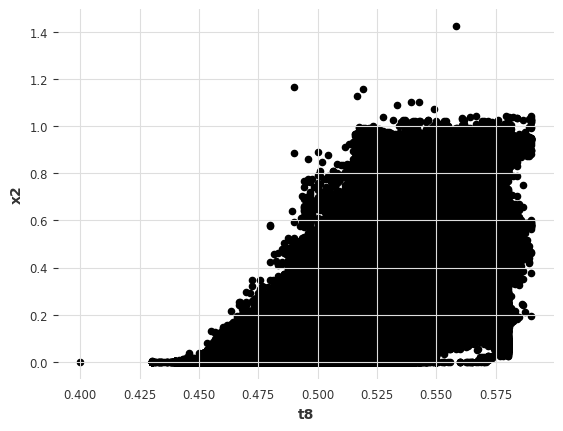

In [24]:
df.plot(x="t8", y="x2", kind="scatter")

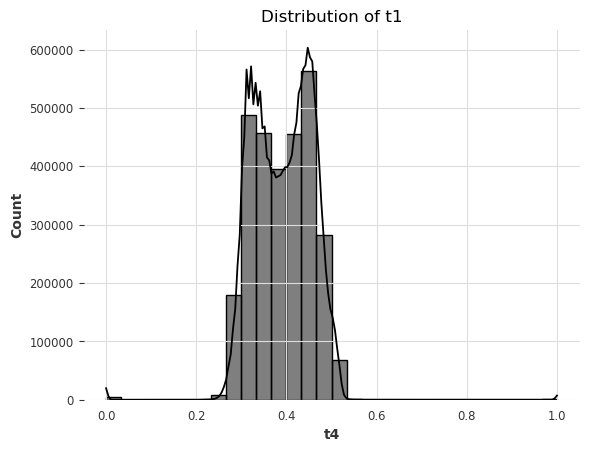

In [53]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df["t4"], bins=30, kde=True)
plt.title("Distribution of t1")
plt.show()

In [47]:
df = pd.read_csv('train_hourly.csv')


def augment_df(df, dropId = True):
    df = df.merge(devices, on="deviceId", how="left")

    df["timedate"] = pd.to_datetime(df["hour"], utc=True)

    # encode time features
    df["year"] = df["timedate"].dt.year
    df["month"] = df["timedate"].dt.month
    df["hour"] = df["timedate"].dt.hour

    #df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * (df["month"]) / 12)

    df["hour_sin"] = np.sin(2 * np.pi * (df["hour"] + 5) / 24)
    #df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

    #df["temp_diff"] = df["t1"] - (df["t2"]- 0.5)/ 4

    #df["is_weekend"] =  df["timedate"].dt.day >= 6

    df.drop(columns=["timedate", "hour", "period"], inplace=True)

    if dropId:
        df.drop(columns=["deviceId", "year", "month"], inplace=True) 

    temp_cols = [col for col in df.columns if col.startswith("t")]

    for col in temp_cols:
        lower = df[col].quantile(0.02)
        upper = df[col].quantile(0.98)
        df[col] = df[col].clip(lower, upper)

    df['a1'] = df['t4'] * df['t8']
    df['a2'] = df['t4'] / df['t8']
    #df['a3'] = df['t8'] / df['t4']
    df['a4'] = df['t4'] + df['t8']
    df['a5'] = df['t4'] * df['t13']

    df['b1'] = df['t5'] - df['t3']
    df['b2'] = df['t6'] - df['t4']

    df['b3'] = df['x3'] * (1 - df['t1_max'])

    df["c1"] = df["t3"] - df["t4"]
    df["c2"] = df["t5"] - df["t6"]
    df["c3"] = df["t10"] - df["t11"]

    

    return df

train_df = augment_df(pd.read_csv('train_hourly.csv'))
valid_df = augment_df(pd.read_csv('valid_hourly.csv'), dropId=False)
test_df = augment_df(pd.read_csv('test_hourly.csv'), dropId=False)

In [48]:
train_df.head()

,t1,t2,t3,t4,t5,t6,t7,t8,t9,t10,...,a1,a2,a4,a5,b1,b2,b3,c1,c2,c3
0,0.290000,0.05,0.0,0.372500,0.446667,0.438333,0.200000,0.499167,0.394167,0.210000,...,0.185940,0.746244,0.871667,0.026075,0.446667,0.065833,5.68,-0.372500,0.008333,0.000000
1,0.290000,0.05,0.0,0.418333,0.464167,0.452500,0.200000,0.514167,0.408333,0.210000,...,0.215093,0.813614,0.932500,0.029632,0.464167,0.034167,5.68,-0.418333,0.011667,0.004167
2,0.290000,0.05,0.0,0.447500,0.477500,0.450000,0.205833,0.530833,0.390000,0.210000,...,0.237548,0.843014,0.978333,0.032817,0.477500,0.002500,5.68,-0.447500,0.027500,0.007500
3,0.286667,0.05,0.0,0.392500,0.459167,0.452500,0.210000,0.506667,0.403333,0.210000,...,0.198867,0.774671,0.899167,0.027802,0.459167,0.060000,5.68,-0.392500,0.006667,0.000833
4,0.280000,0.05,0.0,0.445000,0.473333,0.456667,0.210000,0.521667,0.415000,0.208333,...,0.232142,0.853035,0.966667,0.031521,0.473333,0.011667,5.76,-0.445000,0.016667,0.004167


In [30]:
train_df.shape

(2905879, 23)

In [31]:
split_point = int(0.8 * train_df.shape[0])
train_test_df = train_df[:split_point]
train_valid_df = train_df[split_point:]

In [80]:
class ReduceLROnPlateau(xgb.callback.TrainingCallback):
    
    def __init__(self, factor=0.5, patience=30, min_lr=1e-4, metric_name="test-mae"):
        self.factor = factor
        self.patience = patience
        self.min_lr = min_lr
        self.metric_name = metric_name
        
        self.best_score = float("inf")
        self.wait = 0
        self.current_lr = None

    def after_iteration(self, model, epoch, evals_log):
        
        score = evals_log["test"]["mae"][-1]

        if self.current_lr is None:
            self.current_lr = float(model.attributes().get("eta", 0.03))

        if score < self.best_score:
            self.best_score = score
            self.wait = 0
        else:
            self.wait += 1

        if self.wait >= self.patience:
            new_lr = max(self.current_lr * self.factor, self.min_lr)

            if new_lr < self.current_lr:
                self.current_lr = new_lr
                model.set_param("eta", new_lr)
                print(f"\nReducing learning rate to {new_lr:.6f}\n")

            self.wait = 0

        return False

In [43]:
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.metrics import mean_absolute_error

target = "x2"

X = train_df.drop(columns=[target])
y = train_df[target]

split_idx = int(len(train_df) * 0.8)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

# Convert to DMatrix
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

# Model parameters
params = {
    "objective": "reg:squarederror",
    "eval_metric": "mae",
    "max_depth": 12,
    "eta": 0.03,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
}

# Train model
model = xgb.train(
    params,
    dtrain,
    num_boost_round=1800,
    evals=[(dtrain, "train"), (dtest, "test")],
    early_stopping_rounds=40,
    #callbacks=[reduce_lr]
    #callbacks=[xgb.callback.LearningRateScheduler(lr_schedule)]
)

# Predict
preds = model.predict(dtest)

# Evaluate
rmse = mean_absolute_error(y_test, preds)
print("MAE:", rmse)

[0]	train-mae:0.14045	test-mae:0.13231
[1]	train-mae:0.13644	test-mae:0.12848
[2]	train-mae:0.13254	test-mae:0.12480
[3]	train-mae:0.12878	test-mae:0.12128
[4]	train-mae:0.12512	test-mae:0.11785
[5]	train-mae:0.12158	test-mae:0.11450
[6]	train-mae:0.11815	test-mae:0.11124
[7]	train-mae:0.11483	test-mae:0.10814
[8]	train-mae:0.11195	test-mae:0.10553
[9]	train-mae:0.10882	test-mae:0.10262
[10]	train-mae:0.10579	test-mae:0.09984
[11]	train-mae:0.10316	test-mae:0.09761
[12]	train-mae:0.10032	test-mae:0.09498
[13]	train-mae:0.09755	test-mae:0.09245
[14]	train-mae:0.09488	test-mae:0.09003
[15]	train-mae:0.09257	test-mae:0.08804
[16]	train-mae:0.09008	test-mae:0.08578
[17]	train-mae:0.08764	test-mae:0.08362
[18]	train-mae:0.08528	test-mae:0.08158
[19]	train-mae:0.08300	test-mae:0.07960
[20]	train-mae:0.08079	test-mae:0.07770
[21]	train-mae:0.07865	test-mae:0.07590
[22]	train-mae:0.07659	test-mae:0.07415
[23]	train-mae:0.07488	test-mae:0.07270
[24]	train-mae:0.07294	test-mae:0.07109
[25]	train

In [44]:
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.metrics import mean_absolute_error

target = "x2"

X = train_df.drop(columns=[target])
y = train_df[target]

X_train = X

y_train = y

# Convert to DMatrix
dtrain = xgb.DMatrix(X_train, label=y_train)

# Model parameters
params = {
    "objective": "reg:squarederror",
    "eval_metric": "mae",
    "max_depth": 12,
    "eta": 0.03,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
}

# Train model
model = xgb.train(
    params,
    dtrain,
    num_boost_round=300,
    evals=[(dtrain, "train")],
    early_stopping_rounds=20,
)

# Predict
#preds = model.predict(dtest)

# Evaluate
#rmse = mean_absolute_error(y_test, preds)
#print("MAE:", rmse)

[0]	train-mae:0.13862
[1]	train-mae:0.13465
[2]	train-mae:0.13081
[3]	train-mae:0.12711
[4]	train-mae:0.12351
[5]	train-mae:0.12002
[6]	train-mae:0.11663
[7]	train-mae:0.11336
[8]	train-mae:0.11053
[9]	train-mae:0.10745
[10]	train-mae:0.10447
[11]	train-mae:0.10189
[12]	train-mae:0.09909
[13]	train-mae:0.09637
[14]	train-mae:0.09375
[15]	train-mae:0.09150
[16]	train-mae:0.08905
[17]	train-mae:0.08666
[18]	train-mae:0.08434
[19]	train-mae:0.08210
[20]	train-mae:0.07994
[21]	train-mae:0.07784
[22]	train-mae:0.07582
[23]	train-mae:0.07415
[24]	train-mae:0.07226
[25]	train-mae:0.07064
[26]	train-mae:0.06885
[27]	train-mae:0.06714
[28]	train-mae:0.06547
[29]	train-mae:0.06387
[30]	train-mae:0.06231
[31]	train-mae:0.06081
[32]	train-mae:0.05935
[33]	train-mae:0.05795
[34]	train-mae:0.05659
[35]	train-mae:0.05528
[36]	train-mae:0.05419
[37]	train-mae:0.05297
[38]	train-mae:0.05178
[39]	train-mae:0.05064
[40]	train-mae:0.04954
[41]	train-mae:0.04859
[42]	train-mae:0.04754
[43]	train-mae:0.0465

In [45]:
target = "x2"

full_test = pd.concat([valid_df, test_df], ignore_index=True)
feature_cols = [c for c in full_test.columns if c not in ['x2', 'deviceId', 'year', 'month']]

X_submit = full_test[feature_cols]
dsubmit = xgb.DMatrix(X_submit)
full_test['prediction'] = np.clip(model.predict(dsubmit), 0, None)

submission = (
    full_test.groupby(['deviceId', 'year', 'month'])['prediction']
    .mean()
    .reset_index()
)

# 5. Format and Save
# Ensure the columns match the submission requirements exactly
submission = submission[['deviceId', 'year', 'month', 'prediction']]
pd.DataFrame.to_parquet(submission, 'submission.parquet')
submission.to_csv("submission.csv", index=False)

print(f"Submission file created with {len(submission)} rows.")
print(submission.head())

Submission file created with 3559 rows.
                                            deviceId  year  month  prediction
0  000cc3cb7f030c3d0c481bd0e7cf42ee283012c3cb5bfc...  2025      5    0.076151
1  000cc3cb7f030c3d0c481bd0e7cf42ee283012c3cb5bfc...  2025      6    0.016705
2  000cc3cb7f030c3d0c481bd0e7cf42ee283012c3cb5bfc...  2025      7    0.013307
3  000cc3cb7f030c3d0c481bd0e7cf42ee283012c3cb5bfc...  2025      8    0.019671
4  000cc3cb7f030c3d0c481bd0e7cf42ee283012c3cb5bfc...  2025      9    0.052829


In [25]:
pd.read_csv('submission.csv').head()

,deviceId,year,month,prediction
0,000cc3cb7f030c3d0c481bd0e7cf42ee283012c3cb5bfc...,2025,5,0.086681
1,000cc3cb7f030c3d0c481bd0e7cf42ee283012c3cb5bfc...,2025,6,0.019781
2,000cc3cb7f030c3d0c481bd0e7cf42ee283012c3cb5bfc...,2025,7,0.018379
3,000cc3cb7f030c3d0c481bd0e7cf42ee283012c3cb5bfc...,2025,8,0.023694
4,000cc3cb7f030c3d0c481bd0e7cf42ee283012c3cb5bfc...,2025,9,0.057270


In [10]:
submission.value_counts('deviceId')

deviceId
ffd5e815486d2b094a0ff197111e96c998e11fda1626f71f176af4b1c3296d4e    6
000cc3cb7f030c3d0c481bd0e7cf42ee283012c3cb5bfc93ae46eecc5798f0fe    6
005767201ec5d7c3336b3b4d1ffa8a72e7ca1ecdaac30fe5a99d7a76b53f9fc9    6
01668c64ccc16c506a7c1a5c032e2eb5e2de48ecb284f2e1f6ac48b9de8ad5dd    6
01bf745bf2df0312bd5ff2234c0e9dedc39ad0bac9bcfcc89f1f92902934f571    6
                                                                   ..
c5761e3bb51a4736bafd9ef9cba827f52b34291ae62760174293078803186264    3
71e933de062f206b3c75ab7e2f85d8cbcad40c0e2be9c9f6f041d73f0e8349e1    3
9836b6354391c6892c17b1d7e36230d122fb5f5c5b741044e00bbed4335a1596    3
25ed3d2359d3509aba1c90d746c800802f5dbd101683b4afba1b568711dbf61b    3
2b6cc01a05292397d20f7a64b2b399197d04057091b776522c198f7dd2bd60a3    3
Name: count, Length: 600, dtype: int64

In [7]:
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error

target = "x2"

X = train_df.drop(columns=[target])
y = train_df[target]

split_idx = int(len(train_df) * 0.8)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

model = lgb.LGBMRegressor(
    n_estimators=1500,
    learning_rate=0.03,
    max_depth=12,
    subsample=0.8,
    colsample_bytree=0.8
)

model.fit(X_train, y_train)

preds = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, preds))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.022731 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2516
[LightGBM] [Info] Number of data points in the train set: 2324703, number of used features: 21
[LightGBM] [Info] Start training from score 0.158614
MAE: 0.03455384754932122
